In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os



In [11]:
path_sub = Path('sampled.ndjson')
df_sub = pd.read_json(path_sub, lines= True) 
df_sub.head()



,id,author,created_utc,ups,downs,likes,num_comments,selftext,title,subreddit,best_topic_index,best_topic,best_topic_similarity
0,1dc82va,clonedhuman,1717977620000,1,0,NaN,2,,Republicans Try To Block 4 Million Workers Fro...,politics,2,The federal minimum wage should be increased.,0.404026
1,1dcetz6,Kate_Matthews,1718000389000,1071,0,NaN,96,,US pushes for $50 billion loan to Ukraine usin...,politics,3,The US should provide financial and military a...,0.616209
2,1dch1vs,LbextDipsBenchPlatty,1718010068000,1,0,NaN,1,,The risks of AI could be catastrophic. We shou...,politics,17,Artificial Intelligence should replace humans ...,0.517387
3,1dcjmbw,eustachian_lube,1718020314000,0,0,NaN,43,,The California Minimum-Wage Disaster,politics,2,The federal minimum wage should be increased.,0.603124
4,1dcngsr,Ok-Story-9319,1718031298000,1,0,NaN,1,[removed],The U.S. Economy is Absolutely Fantastic,politics,4,A universal basic income would kill the economy.,0.458117


In [12]:
subreddit_dist = (
    df_sub["subreddit"]
    .value_counts(dropna=False)
    .rename_axis("subreddit")
    .reset_index(name="count")
)

subreddit_dist["share"] = subreddit_dist["count"] / subreddit_dist["count"].sum()

subreddit_dist

,subreddit,count,share
0,AskReddit,2019,0.64608
1,worldnews,436,0.13952
2,Conservative,239,0.07648
3,changemyview,154,0.04928
4,PoliticalDiscussion,111,0.03552
5,AmItheAsshole,105,0.03360
6,moderatepolitics,19,0.00608
7,politics,16,0.00512
8,Liberal,14,0.00448
9,Debate,9,0.00288


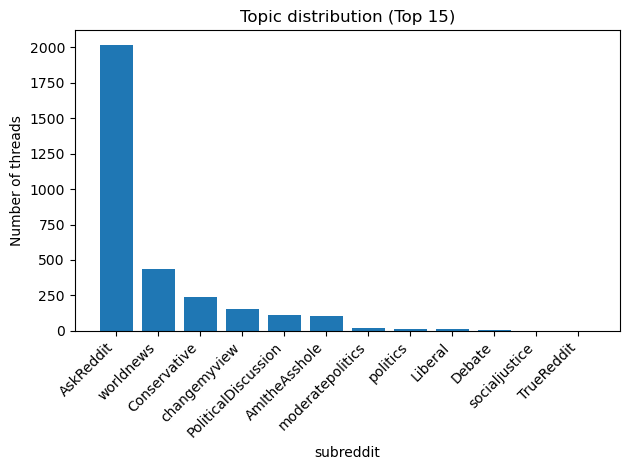

In [14]:
top_n = 15
plot_df = subreddit_dist.head(top_n)

plt.figure()
plt.bar(plot_df["subreddit"].astype(str), plot_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Topic distribution (Top {})".format(top_n))
plt.ylabel("Number of threads")
plt.xlabel("subreddit")
plt.tight_layout()
plt.show()

In [9]:
path_merged = Path("data/conversation_threads_flat.ndjson")
df_merged = pd.read_json(path_merged, lines=True)


In [10]:
subreddit_dist = (
    df_merged["subreddit"]
    .value_counts(dropna=False)
    .rename_axis("subreddit")
    .reset_index(name="count")
)

subreddit_dist["share"] = subreddit_dist["count"] / subreddit_dist["count"].sum()

subreddit_dist

,subreddit,count,share
0,AskReddit,31225,0.617498
1,changemyview,13707,0.271066
2,AmItheAsshole,3200,0.063282
3,PoliticalDiscussion,2266,0.044812
4,TrueReddit,145,0.002867
5,Debate,24,0.000475
